This model is intended to work for services provided by HCl Software such as HCL AppScan for security testing, HCL VoltMX for low-code development, HCL Commerce+ for e-commerce, etc.

Dataset has been sourced from [Kaggle](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset). It has over 64,000 datapoints, with features including customer age, gender, product usage frequency, number of suport calls, contract length, total expenditure, subscription type (basic/standar/premium), etc.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

!pip install catboost
from catboost import CatBoostClassifier

from sklearn.utils import resample

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/HCL hackon/customer_churn_dataset.csv')
df = df[:60_000]
df_majority = df[df['Churn'] == 0]
df_minority = df[df['Churn'] == 1]

print(f"Original majority (0) count: {df_majority.shape[0]}")
print(f"Original minority (1) count: {df_minority.shape[0]}")

df_1 = df_minority.sample(n=df_minority.shape[0] - 5000, random_state=42)
df_0 = df_majority
df = pd.concat([df_0, df_1])
print(df.shape)
print(f"Original majority (0) count: {df_0.shape[0]}")
print(f"Original minority (1) count: {df_1.shape[0]}")

Original majority (0) count: 33881
Original minority (1) count: 26119
(55000, 12)
Original majority (0) count: 33881
Original minority (1) count: 21119


In [ ]:
df.info()
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 55000 entries, 1 to 47943
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         55000 non-null  int64 
 1   Age                55000 non-null  int64 
 2   Gender             55000 non-null  object
 3   Tenure             55000 non-null  int64 
 4   Usage Frequency    55000 non-null  int64 
 5   Support Calls      55000 non-null  int64 
 6   Payment Delay      55000 non-null  int64 
 7   Subscription Type  55000 non-null  object
 8   Contract Length    55000 non-null  object
 9   Total Spend        55000 non-null  int64 
 10  Last Interaction   55000 non-null  int64 
 11  Churn              55000 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.5+ MB

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Con

# Data Preprocessing
Since no empty/missing fields were found in the dataset, we proceed to transform categorical data into numerical data using direct encoding. Categories needing transformation are:

1.   Gender (0)
2.   Subscription Type (1)
3.   Contract Length (2)

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Subscription Type'] = le.fit_transform(df['Subscription Type'])
df['Contract Length'] = le.fit_transform(df['Contract Length'])

# Data Visualisation


*   The box plot showed that there are no outliers.
*   Heatmap suggests that Payment
Delay, CustomerID, Support calls, etc. have significant correlation (0.3 - 0.5). The CustomerID correlation seems to be an exception/coincidence with no logical bases so it has been dropped.
*   The Pie Chart initially showed a skewed distribution which was then balanced by undersampling data points from majority label (1).



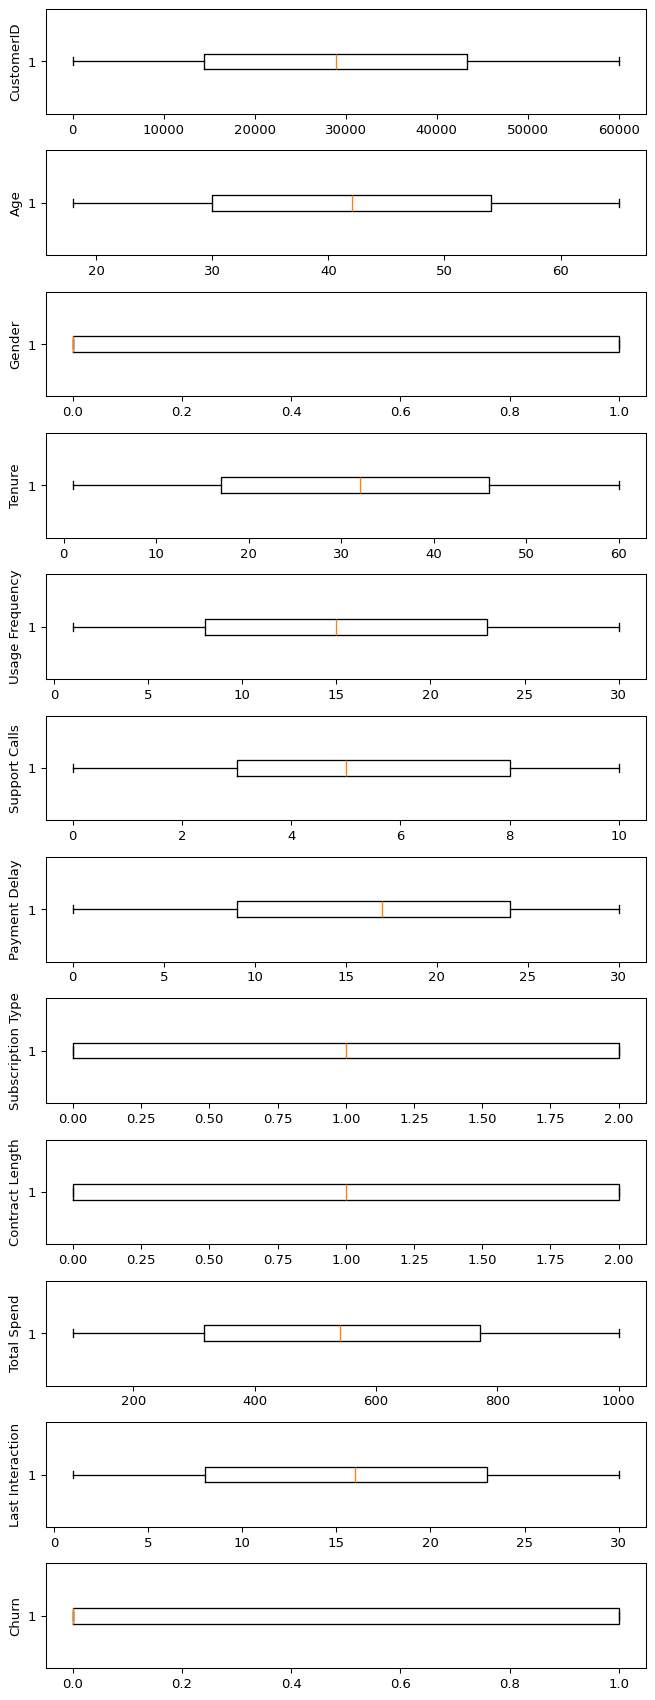

In [ ]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

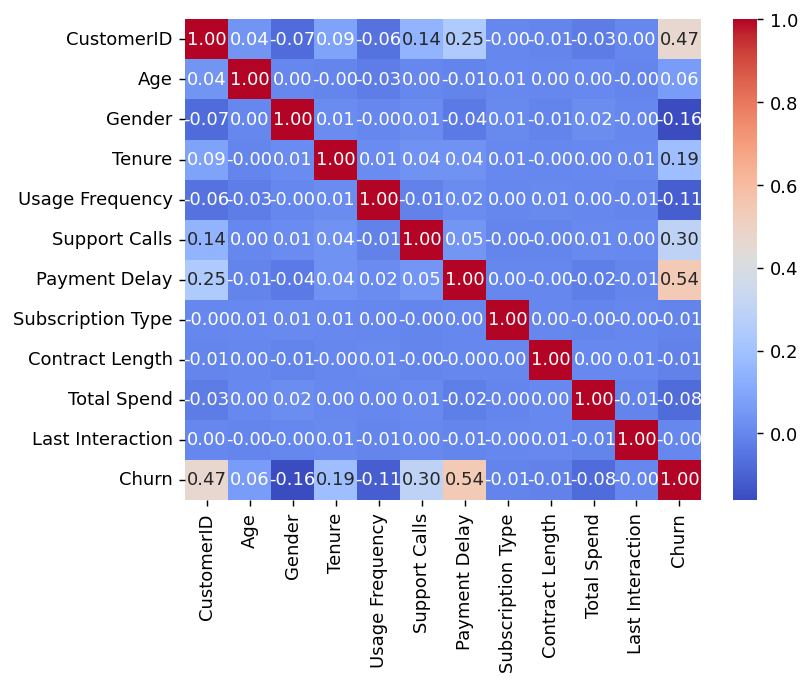

Churn                1.000000
Payment Delay        0.538098
CustomerID           0.467582
Support Calls        0.295046
Tenure               0.188246
Age                  0.064059
Last Interaction    -0.000123
Subscription Type   -0.007176
Contract Length     -0.013056
Total Spend         -0.075432
Usage Frequency     -0.114997
Gender              -0.160842
Name: Churn, dtype: float64


In [ ]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Churn'].sort_values(ascending=False))

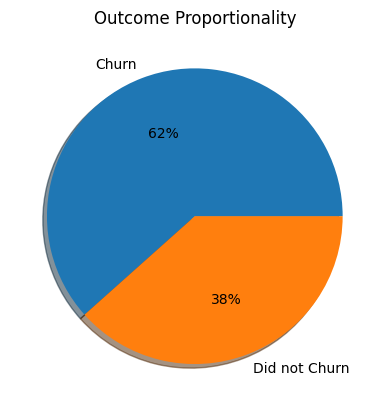

In [ ]:
plt.pie(df['Churn'].value_counts(), labels=[
        'Churn', 'Did not Churn'], autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()

In [ ]:
X = df[['Payment Delay', 'Support Calls', 'Tenure', 'Age',
        'Last Interaction', 'Subscription Type', 'Contract Length',
        'Total Spend', 'Usage Frequency', 'Gender']]
y = df['Churn']

In [ ]:
undersample = RandomUnderSampler(sampling_strategy='majority')
X_under, y_under = undersample.fit_resample(X, y)
print("Undersampled class distribution:", Counter(y_under))

Undersampled class distribution: Counter({0: 21119, 1: 21119})


# Normalization
Normalization of the following features has been done:

1.   Payment Delay
2.   Support Calls
3.   Tenure
4.   Age
5.   Last Interaction
6.   Subscription Type
7.   Contract Length
8.   Total Spend
9.   Usage Frequency
10.  Gender


In [ ]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
# print(X_normalized[:5])

# Standardization
Standarda

In [ ]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
# print(X_standardized[:5])

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, test_size=0.2, random_state=42)

In [ ]:
# Train the Logistic Regression model
LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)

# drive_path = "/content/drive/MyDrive/HCL hackon/my_sklearn_model.joblib"
# joblib.dump(model, drive_path)





LogisticRegression()

In [ ]:
# Evaluate the model
y_pred = LR_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 82.95%

Confusion Matrix:
 [[5902  875]
 [1001 3222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      6777
           1       0.79      0.76      0.77      4223

    accuracy                           0.83     11000
   macro avg       0.82      0.82      0.82     11000
weighted avg       0.83      0.83      0.83     11000



In [ ]:
param_grid = {
    'n_estimators': [20, 50, 100, 115, 150, 170, 200],
    'max_depth': [None, 14, 20, 26, 32, 38]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'max_depth': 38, 'n_estimators': 200}
Best Estimator: RandomForestClassifier(max_depth=38, n_estimators=200)


In [ ]:
y_pred = grid_search.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9993636363636363

Confusion Matrix:
 [[6775    2]
 [   5 4218]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6777
           1       1.00      1.00      1.00      4223

    accuracy                           1.00     11000
   macro avg       1.00      1.00      1.00     11000
weighted avg       1.00      1.00      1.00     11000



In [ ]:
boost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

boost_model.fit(X_train, y_train)

y_pred = boost_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

drive_path = "/content/drive/MyDrive/HCL hackon/boost_model.joblib"
joblib.dump(boost_model, drive_path)

Accuracy: 0.9999090909090909

Confusion Matrix:
 [[6776    1]
 [   0 4223]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6777
           1       1.00      1.00      1.00      4223

    accuracy                           1.00     11000
   macro avg       1.00      1.00      1.00     11000
weighted avg       1.00      1.00      1.00     11000



['/content/drive/MyDrive/HCL hackon/boost_model.joblib']

In [ ]:
testtt = pd.read_csv('/content/drive/MyDrive/HCL hackon/Som-Test.csv')

dff = testtt[['Payment Delay', 'Support Calls', 'Tenure', 'Age',
        'Last Interaction', 'Subscription Type', 'Contract Length',
        'Total Spend', 'Usage Frequency', 'Gender']]

y_ = testtt['Churn']

dff['Gender'] = le.fit_transform(dff['Gender'])
dff['Subscription Type'] = le.fit_transform(dff['Subscription Type'])
dff['Contract Length'] = le.fit_transform(dff['Contract Length'])

XX_ = scaler.fit_transform(dff)

y_P = boost_model.predict(XX_)
accuracy = accuracy_score(y_, y_P)

print(f"Accuracy: {accuracy}")
print()
print("Confusion Matrix:\n", confusion_matrix(y_, y_P))
print("\nClassification Report:\n", classification_report(y_, y_P))



Accuracy: 0.9629042781247087

Confusion Matrix:
 [[33838    43]
 [ 2345 28148]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     33881
           1       1.00      0.92      0.96     30493

    accuracy                           0.96     64374
   macro avg       0.97      0.96      0.96     64374
weighted avg       0.97      0.96      0.96     64374



/tmp/ipython-input-467378134.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Gender'] = le.fit_transform(dff['Gender'])
/tmp/ipython-input-467378134.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Subscription Type'] = le.fit_transform(dff['Subscription Type'])
/tmp/ipython-input-467378134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://